In [1]:
# Cell 1: Unduh dataset dari Google Drive dan Muat ke Pandas DataFrame
import pandas as pd
import numpy as np
import gdown

# File ID dari link Drive
file_id = '1YS9AzFdYqvrhcDBcEezSLyisCpNTKvXC'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'shipments.csv'

# Download file
gdown.download(url, output, quiet=False)

# Memuat dataset ke dalam Pandas DataFrame
df = pd.read_csv('shipments.csv')

# Tampilkan 5 baris pertama data
df.head()

Downloading...
From: https://drive.google.com/uc?id=1YS9AzFdYqvrhcDBcEezSLyisCpNTKvXC
To: /content/shipments.csv
100%|██████████| 7.43k/7.43k [00:00<00:00, 10.8MB/s]


,tracking_number,courier,weight_kg,distance_km,promised_hours,actual_hours,delay_hours
0,ANT0140,Sari,2.3,50.4,19,26.3,7.3
1,ANT0066,Andi,2.8,14.9,10,13.1,3.1
2,ANT0096,Budi,3.0,26.0,12,17.2,5.2
3,ANT0023,Dedi,3.1,13.6,9,10.3,1.3
4,ANT0064,Andi,2.0,11.5,9,10.8,1.8


In [2]:
# Cell 2: Inspeksi Awal Data
print("=== Ukuran Data (Baris, Kolom) ===")
print(df.shape)

print("\n=== Tipe Data & Info Kolom ===")
print(df.info())

print("\n=== Jumlah Nilai Kosong (Missing Values) ===")
print(df.isnull().sum())

print("\n=== Jumlah Data Duplikat ===")
print(df.duplicated().sum())

=== Ukuran Data (Baris, Kolom) ===
(220, 7)

=== Tipe Data & Info Kolom ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tracking_number  220 non-null    object 
 1   courier          220 non-null    object 
 2   weight_kg        220 non-null    float64
 3   distance_km      220 non-null    float64
 4   promised_hours   220 non-null    int64  
 5   actual_hours     220 non-null    float64
 6   delay_hours      220 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 12.2+ KB
None

=== Jumlah Nilai Kosong (Missing Values) ===
tracking_number    0
courier            0
weight_kg          0
distance_km        0
promised_hours     0
actual_hours       0
delay_hours        0
dtype: int64

=== Jumlah Data Duplikat ===
0


In [3]:
# Cell 3: Data Cleaning & Perhitungan Kolom delay_hours

# 1. Pastikan kolom numerik bertipe numerik (float/int)
numeric_cols = ['weight_kg', 'distance_km', 'promised_hours', 'actual_hours']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Hapus nilai kosong (dropna) dan duplikat (drop_duplicates)
df_clean = df.dropna().drop_duplicates().copy()

# 3. Hitung delay_hours (actual_hours - promised_hours)
# Batas bawah 0: Jika tepat waktu atau lebih cepat (nilai minus), jadikan 0
df_clean['delay_hours'] = (df_clean['actual_hours'] - df_clean['promised_hours']).clip(lower=0)

# Validasi hasil cleaning
print(f"Jumlah baris setelah dibersihkan: {len(df_clean)}")
print(f"Nilai kosong tersisa: {df_clean.isnull().sum().sum()}")
print(f"Data duplikat tersisa: {df_clean.duplicated().sum()}")

# 4. Hitung Statistik Dasar delay_hours menggunakan NumPy
delay_data = df_clean['delay_hours'].values

min_delay = np.min(delay_data)
median_delay = np.median(delay_data)
mean_delay = np.mean(delay_data)
std_delay = np.std(delay_data)

print("\n=== STATISTIK KETERLAMBATAN (delay_hours) ===")
print(f"Minimum         : {min_delay:.2f} jam")
print(f"Median          : {median_delay:.2f} jam")
print(f"Mean (Rata-rata): {mean_delay:.2f} jam")
print(f"Standar Deviasi : {std_delay:.2f} jam")

Jumlah baris setelah dibersihkan: 220
Nilai kosong tersisa: 0
Data duplikat tersisa: 0

=== STATISTIK KETERLAMBATAN (delay_hours) ===
Minimum         : 0.00 jam
Median          : 3.05 jam
Mean (Rata-rata): 4.14 jam
Standar Deviasi : 3.80 jam


=== Hasil Manual Loop (Rata-rata Delay per Kurir) ===
Sari: 5.80 jam
Andi: 2.10 jam
Budi: 3.40 jam
Dedi: 1.60 jam
Citra: 7.90 jam

=== Hasil Pandas groupby() ===
courier  delay_hours
  Citra     7.902326
   Sari     5.800000
   Budi     3.400000
   Andi     2.100000
   Dedi     1.602381


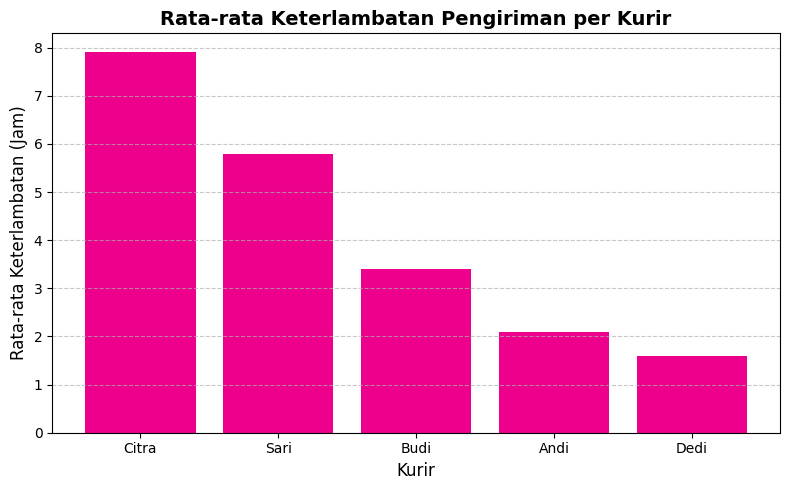


=== ANALISIS KORELASI TERHADAP DELAY (delay_hours) ===
Korelasi Jarak (distance_km) vs Delay : 0.7101
Korelasi Berat (weight_kg) vs Delay   : 0.2198


In [4]:
# Cell 4: Grouping (Loop Manual vs groupby) & Visualisasi Matplotlib
import matplotlib.pyplot as plt

# A. Grouping Manual menggunakan Loop & Dictionary
courier_delay_manual = {}
courier_count_manual = {}

for idx, row in df_clean.iterrows():
    c = row['courier']
    d = row['delay_hours']
    courier_delay_manual[c] = courier_delay_manual.get(c, 0) + d
    courier_count_manual[c] = courier_count_manual.get(c, 0) + 1

manual_avg_delay = {c: courier_delay_manual[c] / courier_count_manual[c] for c in courier_delay_manual}

print("=== Hasil Manual Loop (Rata-rata Delay per Kurir) ===")
for c, avg in manual_avg_delay.items():
    print(f"{c}: {avg:.2f} jam")

# B. Grouping dengan Pandas groupby()
groupby_avg_delay = df_clean.groupby('courier')['delay_hours'].mean().reset_index()
groupby_avg_delay = groupby_avg_delay.sort_values(by='delay_hours', ascending=False)

print("\n=== Hasil Pandas groupby() ===")
print(groupby_avg_delay.to_string(index=False))

# C. Visualisasi Bar Chart menggunakan Matplotlib
plt.figure(figsize=(8, 5))
plt.bar(groupby_avg_delay['courier'], groupby_avg_delay['delay_hours'], color='#EC008C') # Warna Anteraja Magenta
plt.title('Rata-rata Keterlambatan Pengiriman per Kurir', fontsize=14, fontweight='bold')
plt.xlabel('Kurir', fontsize=12)
plt.ylabel('Rata-rata Keterlambatan (Jam)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# D. Analisis Korelasi
corr_distance = df_clean['distance_km'].corr(df_clean['delay_hours'])
corr_weight = df_clean['weight_kg'].corr(df_clean['delay_hours'])

print("\n=== ANALISIS KORELASI TERHADAP DELAY (delay_hours) ===")
print(f"Korelasi Jarak (distance_km) vs Delay : {corr_distance:.4f}")
print(f"Korelasi Berat (weight_kg) vs Delay   : {corr_weight:.4f}")

In [5]:
# Cell 5: Linear Regression Modeling & Business Insight
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Feature Selection & Train-Test Split
X = df_clean[['distance_km', 'weight_kg', 'promised_hours']]
y = df_clean['delay_hours']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Predict & Evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== EVALUASI MODEL LINEAR REGRESSION ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"R-squared (R2 Score)     : {r2:.4f}")

# 4. Komparasi Rate Keterlambatan: Jarak Jauh (>50 km) vs Jarak Dekat (<10 km)
long_distance = df_clean[df_clean['distance_km'] > 50]
short_distance = df_clean[df_clean['distance_km'] < 10]

# Threshold keterlambatan signifikan (misal > 2 jam)
delay_threshold = 2.0

long_delay_rate = (long_distance['delay_hours'] > delay_threshold).mean() * 100
short_delay_rate = (short_distance['delay_hours'] > delay_threshold).mean() * 100

ratio = long_delay_rate / short_delay_rate if short_delay_rate > 0 else 0

print("\n=== ANALISIS PENGIRIMAN BERDASARKAN JARAK ===")
print(f"Persentase Keterlambatan >2 jam (Jarak Dekat <10 km) : {short_delay_rate:.2f}%")
print(f"Persentase Keterlambatan >2 jam (Jarak Jauh >50 km)  : {long_delay_rate:.2f}%")
print(f"Rasio Perbandingan                                   : {ratio:.2f}x lebih sering")

print("\n=== INSIGHT BISNIS OPERASIONAL ===")
insight_text = f"Pengiriman di atas 50 km mengalami keterlambatan >2 jam {ratio:.1f}× lebih sering dibandingkan pengiriman di bawah 10 km ({long_delay_rate:.1f}% vs {short_delay_rate:.1f}%), sehingga diperlukan alokasi armada prioritas atau penyesuaian SLA estimasi waktu pada rute jarak jauh."
print(insight_text)

=== EVALUASI MODEL LINEAR REGRESSION ===
Mean Squared Error (MSE) : 6.0032
R-squared (R2 Score)     : 0.5242

=== ANALISIS PENGIRIMAN BERDASARKAN JARAK ===
Persentase Keterlambatan >2 jam (Jarak Dekat <10 km) : 9.26%
Persentase Keterlambatan >2 jam (Jarak Jauh >50 km)  : 100.00%
Rasio Perbandingan                                   : 10.80x lebih sering

=== INSIGHT BISNIS OPERASIONAL ===
Pengiriman di atas 50 km mengalami keterlambatan >2 jam 10.8× lebih sering dibandingkan pengiriman di bawah 10 km (100.0% vs 9.3%), sehingga diperlukan alokasi armada prioritas atau penyesuaian SLA estimasi waktu pada rute jarak jauh.
